**IEEE-CIS fraud detection**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import prepare_data

### 1) Downloading the dataset

In [10]:
prepare_data.check_download()
trans, id = prepare_data.load_data()

The dataset is already downloaded


### 2) Preparation for EDA: merging the tables
##### transaction table is merged with identity table via left join since transactions with missing identity (the majority of them) should be taken into account.

In [3]:
trans_id_merged = pd.merge(trans, id, on="TransactionID", how="left")

In [4]:
print("transactions shape:", trans.shape)
print("identities shape:", id.shape)
print("merged table shape:", trans_id_merged.shape)

transactions shape: (590540, 394)
identities shape: (144233, 41)
merged table shape: (590540, 434)


### 3) EDA

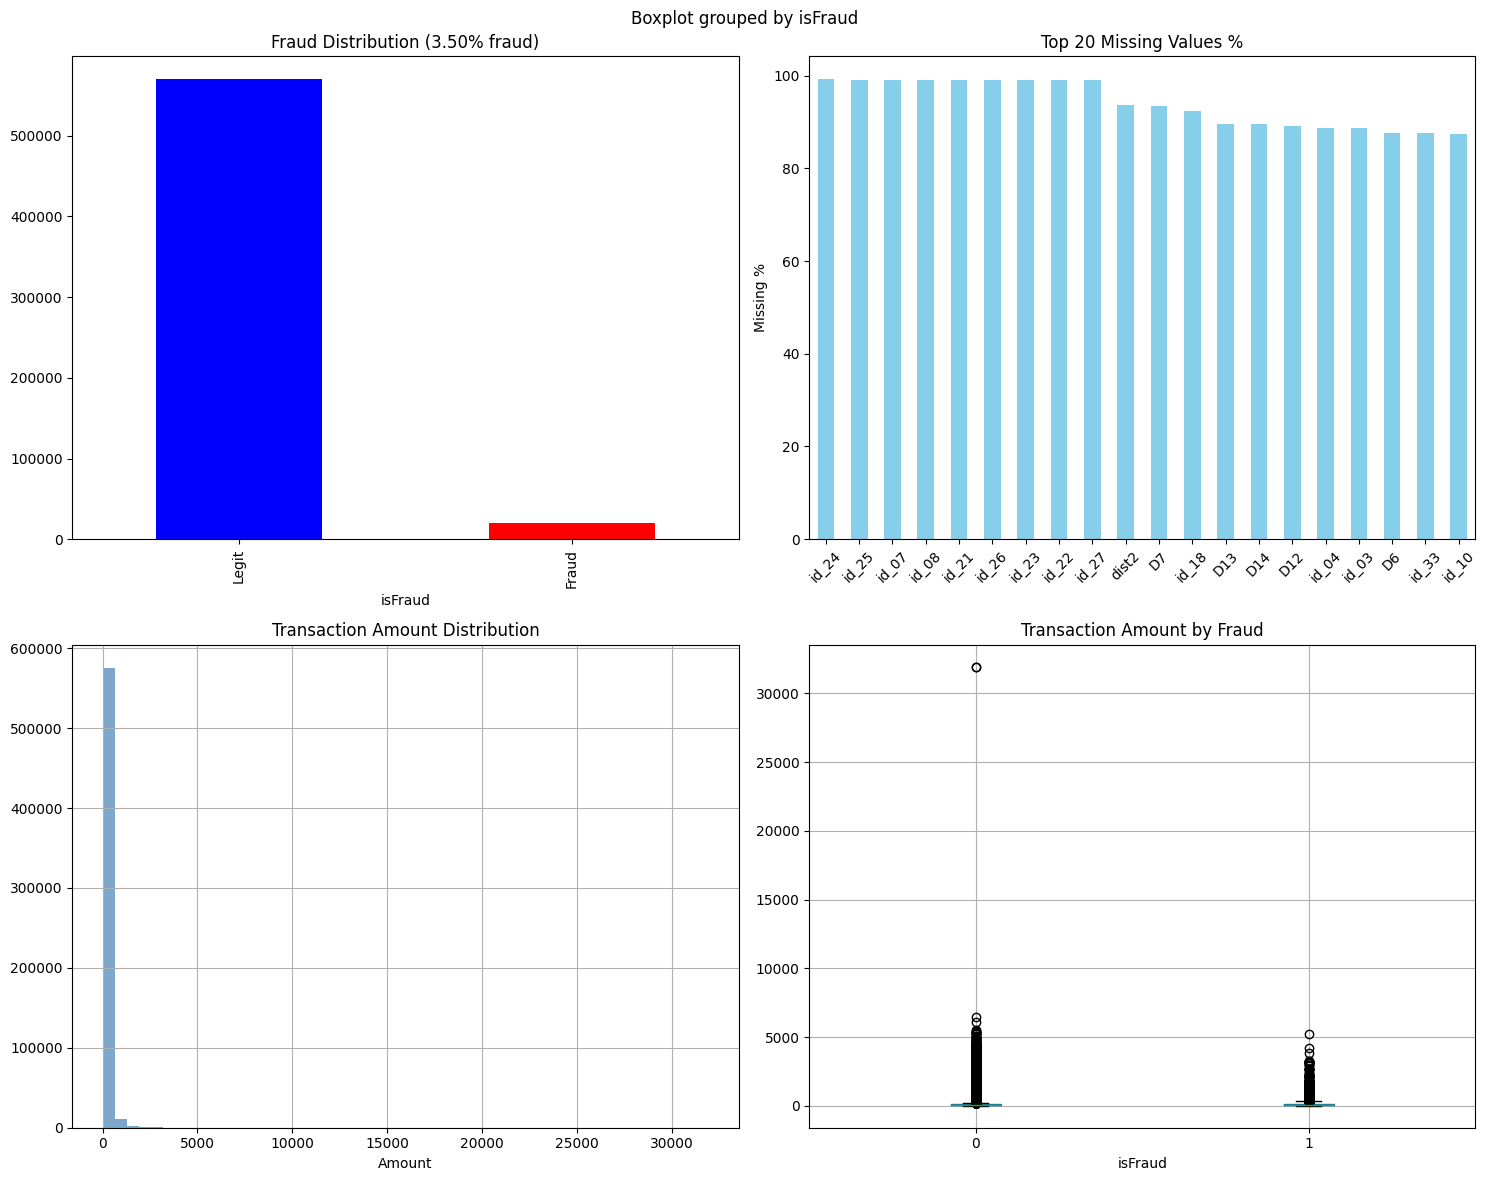


Key Statistics:
- Fraud rate: 3.50%
- Features with >50% missing: 20
- Avg transaction amount: $135.03
- Unique cards: 13553


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# fraudery percentage in a dataset
ax = axes[0, 0]
fraud_pct = trans_id_merged['isFraud'].mean() * 100
trans_id_merged['isFraud'].value_counts().plot(kind='bar', ax=ax, color=['blue', 'red'])

ax.set_title(f'Fraud Distribution ({fraud_pct:.2f}% fraud)')
ax.set_xticklabels(['Legit', 'Fraud'])

# Top 20 Missing Values 
ax = axes[0, 1]
missing = (trans_id_merged.isnull().sum() / len(trans_id_merged)) * 100
missing = missing[missing > 0].sort_values(ascending=False).head(20)
missing.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Top 20 Missing Values %')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=45)

# 3.3 Transaction amount distribution
ax = axes[1, 0]
trans_id_merged['TransactionAmt'].hist(bins=50, ax=ax, alpha=0.7, color='steelblue')
ax.set_title('Transaction Amount Distribution')
ax.set_xlabel('Amount')

# 3.4 Transaction amount by fraud
ax = axes[1, 1]
trans_id_merged.boxplot(column='TransactionAmt', by='isFraud', ax=ax)
ax.set_title('Transaction Amount by Fraud')
ax.set_xlabel('isFraud')

plt.tight_layout()
plt.show()

# Print key stats
print(f"\nKey Statistics:")
print(f"- Fraud rate: {fraud_pct:.2f}%")
print(f"- Features with >50% missing: {(missing > 50).sum()}")
print(f"- Avg transaction amount: ${trans_id_merged['TransactionAmt'].mean():.2f}")
print(f"- Unique cards: {trans_id_merged['card1'].nunique()}")


### 4) Preprocessing

In [6]:
# Process train and test
data_processed = prepare_data.preprocess(trans_id_merged)

print(f"Processed train shape: {data_processed.shape}")

Processed train shape: (590540, 437)


### 5) Train\test splitting


Validation split:
Train: 472,432 samples (86400 to 12192842)
Test: 118,108 samples (12192900 to 15811131)

Fraud rates:
Train fraud rate: 3.51%
Test fraud rate: 3.44%


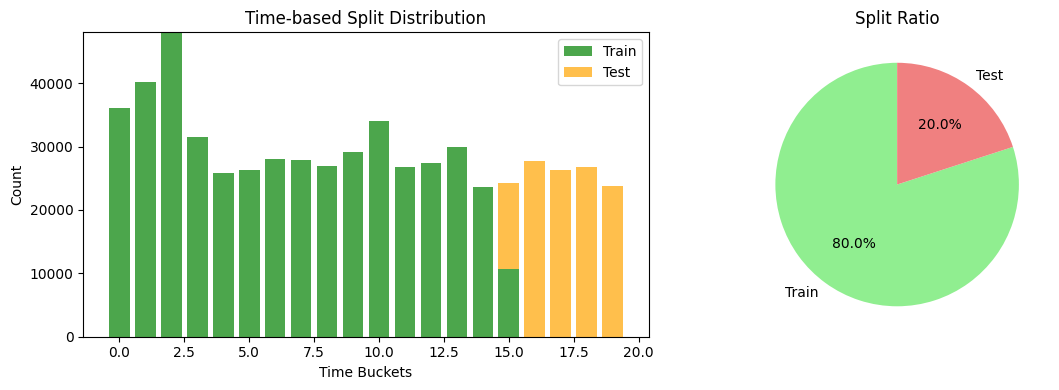

In [13]:
data_sorted = data_processed.sort_values('TransactionDT').reset_index(drop=True)
split_idx = int(0.8 * len(data_sorted))
train, test = prepare_data.split(data_sorted, split_idx)

print(f"\nValidation split:")
print(f"Train: {len(train):,} samples ({train['TransactionDT'].min()} to {train['TransactionDT'].max()})")
print(f"Test: {len(test):,} samples ({test['TransactionDT'].min()} to {test['TransactionDT'].max()})")

# Check fraud rate consistency
print(f"\nFraud rates:")
print(f"Train fraud rate: {train['isFraud'].mean()*100:.2f}%")
print(f"Test fraud rate: {test['isFraud'].mean()*100:.2f}%")

# Visualize split
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Time series plot
time_bins = pd.cut(data_sorted['TransactionDT'], bins=20)

train_counts = train.groupby(time_bins.iloc[:split_idx]).size().reindex(time_bins.cat.categories, fill_value=0)
test_counts = test.groupby(time_bins.iloc[split_idx:]).size().reindex(time_bins.cat.categories, fill_value=0)

ax1.bar(range(len(train_counts)), train_counts.values, alpha=0.7, label='Train', color='green')
ax1.bar(range(len(test_counts)), test_counts.values, alpha=0.7, label='Test', color='orange', bottom=train_counts.values)
ax1.set_title('Time-based Split Distribution')
ax1.set_xlabel('Time Buckets')
ax1.set_ylabel('Count')
ax1.legend()

# Pie chart
ax2.pie([len(train), len(test)], labels=['Train', 'Test'], 
        autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
ax2.set_title('Split Ratio')

plt.tight_layout()
plt.show()